# Computational Medicine, Practical 3  
# Population-level data analysis for digital twin cohort selection  

Week 8, Hilary Term 2024  

Practical leader: Ambre Bertrand ambre.bertrand@cs.ox.ac.uk  
Course lecturer: Blanca Rodriguez blanca.rodriguez@cs.ox.ac.uk  


**Instructions:**  
1. Download/Upload the 3 csv files.  
2. Work your way through the notebook, cell by cell. To run a cell in the notebook, click the little tick in the top right corner, or press Cmd+Enter. To edit a markdown cell (text only), double click on the cell. Fill in the gaps in each cell when prompted.

In [1]:
# import required python libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, chi2_contingency

import warnings
warnings.filterwarnings('ignore')

#############################################################################
# TODO - enter the path to the directory you downloaded the csv files

# local path, if using your own computer
# PATH_practical = ...

# # path if using Colab (empty, root directory)
PATH_practical = ''

#############################################################################


# 1. Exploring the UK Biobank

Before we start, let's explore different types of data and fields to become familiar with the structure of the UK Biobank.  

https://biobank.ndph.ox.ac.uk/showcase/search.cgi   

Which field/instance/array is used to encode the following? Double click to edit the cell with your answers after the arrows

1) Ethnic background  

-->  21 000

2) High density lipoprotein (HDL) cholesterol, units mmol/L, measured at the baseline assessment (tip: look in the ‘Blood Biochemistry’ category)  

--> 30760-0

3) Manual reading of diastolic blood pressure, measured at the first follow-up assessment, first reading  

--> 94-1.0



# 2. Population demographic factors

Read the abstract and Table 1 of this paper:   
  
https://pubmed.ncbi.nlm.nih.gov/31522551/   
  
**What is the aim of their study? Which clinical factors do they include? Why may this information be relevant?**   

--> The aim of their study was to detect early signs of diabetes in cardiac MRI scans. It is relevant because early detection allows for better treatment and no surprise fatalities.
  

Let's start by defining our cohort characteristics. We will be using the following fields, fill in what they correspond to here:


In [10]:
#############################################################################
# TODO -- fill in the missing fields numbers using the search tool and run the cell

sex = 31
ethnic_background = 21000
weight = 12143
height = 12144
smoking_status = 20116
date_of_attending_assessment_centre = 53
age_when_attended_assessment_centre = 21003
systolic_blood_pressure_automated = 4080
diastolic_blood_pressure_automated = 4079
systolic_blood_pressure_manual = 93
diastolic_blood_pressure_manual = 94

eid = 'eid'    # patient IDs are called eid

#############################################################################

# create column names based on time of assessment
# -0.x = baseline assessment, -2.x = imaging+ecg assessment
# x.0 = first reading, x.1 = second reading

columns = ['eid', str(date_of_attending_assessment_centre)+'-2.0',
           str(age_when_attended_assessment_centre)+'-2.0',
           str(sex)+'-0.0', str(ethnic_background)+'-0.0',
           str(weight)+'-2.0', str(height)+'-2.0', str(smoking_status)+'-2.0',
           str(systolic_blood_pressure_automated)+'-2.0', str(systolic_blood_pressure_automated)+'-2.1',
           str(systolic_blood_pressure_manual)+'-2.0', str(systolic_blood_pressure_manual)+'-2.1',
           str(diastolic_blood_pressure_automated)+'-2.0', str(diastolic_blood_pressure_automated)+'-2.1',
           str(diastolic_blood_pressure_manual)+'-2.0', str(diastolic_blood_pressure_manual)+'-2.1',
           ]

# load and view data
df_demographics = pd.read_csv(PATH_practical+'ukb_demographics.csv')[columns]       # load data
df_demographics.head()                                                              # display first 5 rows of dataframe


,eid,53-2.0,21003-2.0,31-0.0,21000-0.0,12143-2.0,12144-2.0,20116-2.0,4080-2.0,4080-2.1,93-2.0,93-2.1,4079-2.0,4079-2.1,94-2.0,94-2.1
0,100000,NaN,NaN,0.0,1001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100001,NaN,NaN,1.0,1001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100002,NaN,NaN,0.0,1001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100003,NaN,NaN,0.0,1001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100004,NaN,NaN,1.0,1002.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#############################################################################
# TODO -- calculate BMI by looking up the formula online
# hint 1: use the fields for weight and height recorded at the second visit
# hint 2: take care with units! in UKB, weight is in kg, height in cm
# hint 3: using the pandas (pd) library, you can add/subtract/multiply/divide columns

df_demographics['bmi'] = df_demographics["12143-2.0"] / (df_demographics["12144-2.0"]/100)**2

#############################################################################

# show some non null values of bmi
df_demographics[~df_demographics['bmi'].isna()]['bmi']


,bmi
7,22.675737
22,22.031726
25,21.048048
50,30.110279
62,27.587326
...,...
502449,22.837370
502457,34.963580
502462,21.007668
502484,30.385016


In [12]:
#############################################################################
# run these functions to simplify encoding for ethnicity and smoking status

# ethicity: 1 white, 2 black, 0 other
# smoking: 0 never, 1 previous, 2 current

col_ethnicity = str(ethnic_background)+'-0.0'
col_smoking = str(smoking_status)+'-0.0'

def replace_ethnicity(x):
    if str(x).startswith('1'):
        # 1 white
        return 1
    elif (str(x) == '2001') | (str(x) == '2002') | (str(x).startswith('4')) :
        # 2 black
        return 2
    else:
        # 0 other
        return 0
df_demographics[col_ethnicity] = df_demographics[col_ethnicity].apply(replace_ethnicity)


def replace_smoking(x):
    if (str(x) == '-3.0') | (str(x) == 'nan'):
        # NaN unknown
        return np.nan
    else:
        # 0 never, 1 previous, 2 current
        return x
df_demographics[col_ethnicity] = df_demographics[col_ethnicity].apply(replace_smoking)

#############################################################################


In [13]:
#############################################################################
# define a function to calculate average blood pressure
# (no action needed, you can check out the function, but it is not needed)

def calculate_avg_bp(df_input):
    # define fields and column names
    fields = {'eid': 'eid',
            '4080-2.0': 'sbp_auto_0',
            '4080-2.1': 'sbp_auto_1',
            '4079-2.0': 'dbp_auto_0',
            '4079-2.1': 'dbp_auto_1',
            '93-2.0': 'sbp_manual_0',
            '93-2.1': 'sbp_manual_1',
            '94-2.0': 'dbp_manual_0',
            '94-2.1': 'dbp_manual_1',}
    df_out = df_input[list(fields.keys())]
    df_out.rename(columns=fields, inplace=True)

    # get average of two readings
    df_out['sbp_auto_avg'] = df_out[['sbp_auto_0', 'sbp_auto_1']].mean(axis=1)
    df_out['dbp_auto_avg'] = df_out[['dbp_auto_0', 'dbp_auto_1']].mean(axis=1)
    df_out['sbp_manual_avg'] = df_out[['sbp_manual_0', 'sbp_manual_1']].mean(axis=1)
    df_out['dbp_manual_avg'] = df_out[['dbp_manual_0', 'dbp_manual_1']].mean(axis=1)

    # get average of auto and manual
    df_out['sbp_avg'] = df_out[['sbp_auto_avg', 'sbp_manual_avg']].mean(axis=1)
    df_out['dbp_avg'] = df_out[['dbp_auto_avg', 'dbp_manual_avg']].mean(axis=1)

    # keep only fields of interest
    df_out = df_out[['eid','sbp_avg','dbp_avg']]

    return df_out

# apply the function
df_bp = calculate_avg_bp(df_demographics)
df_bp

,eid,sbp_avg,dbp_avg
0,100000,NaN,NaN
1,100001,NaN,NaN
2,100002,NaN,NaN
3,100003,NaN,NaN
4,100004,NaN,NaN
...,...,...,...
502485,602485,NaN,NaN
502486,602486,138.5,86.75
502487,602487,NaN,NaN
502488,602488,NaN,NaN


You will notice that some values are empty - why may that be? How can this be dealt with in our analysis?

-->  This can be the case simply because the measurement wasn't taken on that specific taken. In our analysis, we can remove any patient that does not have values for the features we want.

In [15]:
#############################################################################
# TODO -- merge the output with the original dataframe
# hint 1: look up how to merge dataframes (df1, df2) using pandas
# hint 2: aim to do a left merge of df_bp (df2) on df_demographics (df1), on the 'eid' column

df_demo_simplified = pd.merge(df_bp, df_demographics, "left", 'eid')

#############################################################################

# keep only the participants who DO have an imaging+ecg assessment, i.e. visit 2
df_demo_simplified = df_demo_simplified[~df_demo_simplified['53-2.0'].isnull()]
df_demo_simplified

,eid,sbp_avg,dbp_avg,53-2.0,21003-2.0,31-0.0,21000-0.0,12143-2.0,12144-2.0,20116-2.0,4080-2.0,4080-2.1,93-2.0,93-2.1,4079-2.0,4079-2.1,94-2.0,94-2.1,bmi
7,100007,136.75,80.75,2015-03-25 14:26:31.010791582,79.0,0.0,1,64.0,168.0,0.0,155.0,137.0,129.0,126.0,73.0,85.0,77.0,88.0,22.675737
22,100022,122.50,70.00,2016-09-11 08:10:01.552116895,64.0,0.0,1,55.0,158.0,1.0,121.0,135.0,109.0,125.0,65.0,69.0,72.0,74.0,22.031726
25,100025,127.00,80.75,2016-01-25 05:51:09.954129657,66.0,0.0,1,58.0,166.0,1.0,125.0,154.0,124.0,105.0,98.0,73.0,81.0,71.0,21.048048
50,100050,143.00,74.75,2016-12-28 00:03:07.020511103,65.0,0.0,1,80.0,163.0,0.0,157.0,157.0,135.0,123.0,91.0,77.0,63.0,68.0,30.110279
62,100062,137.75,82.25,2015-06-04 13:55:52.664527985,68.0,1.0,1,68.0,157.0,1.0,134.0,135.0,163.0,119.0,85.0,73.0,88.0,83.0,27.587326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502449,602449,129.50,82.75,2015-12-31 08:07:31.222535409,49.0,1.0,1,66.0,170.0,0.0,138.0,109.0,143.0,128.0,84.0,88.0,87.0,72.0,22.837370
502457,602457,120.00,73.75,2015-10-23 23:20:05.912965188,52.0,0.0,1,84.0,155.0,0.0,118.0,109.0,126.0,127.0,76.0,60.0,78.0,81.0,34.963580
502462,602462,135.00,76.50,2015-06-14 23:04:05.180262911,72.0,0.0,1,60.0,169.0,1.0,154.0,129.0,128.0,129.0,84.0,70.0,85.0,67.0,21.007668
502484,602484,148.75,77.50,2015-11-19 08:29:20.530627811,68.0,1.0,0,73.0,155.0,0.0,152.0,147.0,171.0,125.0,67.0,85.0,80.0,78.0,30.385016


# 3. Defining disease  

Now, we will move on to defining cardiovascular disease in our population. There are many different ways of establishing and coding disease diagnoses in a clinical setting. In the UK, one of the main pathways to classify diseases is via ICD-10 codes (the World Health Organisation’s International Classification of Diseases).

**Go back to the Search Page in the link above, and explore field 41270 (Diagnoses – ICD10). Pay particular attention to diseases in Chapter IX. What are the ICD-10 codes for congestive heart failure? Ventricular fibrillation? Acute transmural myocardial infarction of anterior wall?**

-->  I50.0 Congestive heart failure
   
-->  I49.0 Ventricular fibrillation and flutter
  
-->  I21.0, Acute transmural myocardial infarction of anterior wall



You will see there are many different codes relating to different cardiovascular conditions. When conducting a study, it is important to give a clear definition of the disease phenotype you are considering. In this practical, we define ischemic heart disease (IHD) using the following codes:  

-	I20 Angina pectoris
-	I21 Acute myocardial infarction
-	I22 Subsequent myocardial infarction
-	I24 Other acute ischaemic heart diseases
-	I25 Chronic ischaemic heart disease

There are two main ways of finding these diagnosis codes in the UK Biobank. The first is via field 41270 which is a summary of hospital episode statistics (HES) records, the other is via records also linked with primary care records (i.e. diagnoses made at a general healthcare practice or linked from other sources). Here, we will be using the latter approach only to define disease.

**Find the 5 different fields relating to the ICD-10 codes for IHD as defined above. Go to the UKB Search Page and enter the code you are looking for, and record the field number for each 'Date [code] first reported' field. I20 is done for you below.**

--> I20:  131296  
  
--> I21:  131298
  
--> I22:  131300
  
--> I24:  131304
  
--> I25:  131306

Now we are ready to start building our cohorts.


In [16]:
#############################################################################
# TODO fill in the corresponding fields you found for the icd-10 codes above

i20 = 131296
i21 = 131298
i22 = 131300
i24 = 131304
i25 = 131306

ihd_codes = [i20, i21, i22, i24, i25]


In [17]:
#############################################################################
# TODO write a short function to convert the integer field numbers to column names in string format with a '-0.0' suffix
# you should result with a list of column names starting with ['eid', '131296-0.0', ... , ..., ]
# hint: make sure you convert integers to strings!
# hint: use the .append() function

# initialise your list of columns, starting with participant ID
columns_ihd = ['eid']

# ----- start function -----

l = [i20, i21, i22, i24, i25]
for field in l:
    columns_ihd.append(str(field)+'-0.0')

# ---- end of function -----

print('Columns : ', columns_ihd)

#############################################################################

df_diseases = pd.read_csv(PATH_practical+'ukb_cv_disease.csv')[columns_ihd]
df_diseases

Columns :  ['eid', '131296-0.0', '131298-0.0', '131300-0.0', '131304-0.0', '131306-0.0']


,eid,131296-0.0,131298-0.0,131300-0.0,131304-0.0,131306-0.0
0,499836,NaN,NaN,NaN,NaN,NaN
1,325294,NaN,NaN,NaN,NaN,NaN
2,481223,NaN,NaN,NaN,NaN,NaN
3,462714,NaN,NaN,NaN,NaN,NaN
4,202837,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
95258,452111,NaN,NaN,NaN,NaN,NaN
95259,343066,NaN,2000-02-22,NaN,NaN,NaN
95260,155225,NaN,NaN,NaN,NaN,NaN
95261,266386,NaN,NaN,NaN,NaN,NaN


You will notice these are ALL the participants with a record of ischemic heart disease, as per our definition and coding system. We want to establish a set of inclusion and exclusion criteria to define our study cohorts.    

For the disease cohort ('cases'), ***include*** participants with a date of IHD record **before** date of assessment.    

For the healthy cohort ('controls'), ***exclude*** participants with a date of IHD record **before** date of assessment

In [18]:
#############################################################################
# left merge df_diseases on df_demo_simplified, on the 'eid' column

df_demo_and_disease = pd.merge(df_diseases, df_demo_simplified, "left", 'eid')
df_demo_and_disease

#############################################################################


,eid,131296-0.0,131298-0.0,131300-0.0,131304-0.0,131306-0.0,sbp_avg,dbp_avg,53-2.0,21003-2.0,...,20116-2.0,4080-2.0,4080-2.1,93-2.0,93-2.1,4079-2.0,4079-2.1,94-2.0,94-2.1,bmi
0,499836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,325294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,481223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,462714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,202837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95258,452111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95259,343066,NaN,2000-02-22,NaN,NaN,NaN,143.25,78.75,2016-04-02 00:58:12.897261212,53.0,...,1.0,132.0,157.0,133.0,151.0,72.0,77.0,75.0,91.0,35.918367
95260,155225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95261,266386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
#############################################################################
# TODO create a new column 'ihd_flag' in the dataframe to create a disease flag where 0 = no IHD and 1 = IHD
# for now, set all values in 'ihd_flag' to 0 - these are the controls
# hint: use numpy zeros and create an array of length equal to the length of the dataframe

df_demo_and_disease['ihd_flag'] = np.zeros_like(df_demo_and_disease['eid'])

#############################################################################

# now change the flag to 1 for the cases:

# get the dates you want to compare
dates_of_disease = columns_ihd[1:]   # all columns apart from eid
date_of_assessment = '53-2.0'        # field number for date of assessment at visit 2

# apply the inclusion criteria for our disease cohort, where date of disease must be less than or equal to date of assessment
# the .any(axis=1) part means that we are checking if ANY disease date across each row/participant (axis 1) fits the criteria of being <= date of assessment
mask = (df_demo_and_disease[dates_of_disease].le(df_demo_and_disease[date_of_assessment], axis=0)).any(axis=1)  # .le means less than or equal to
df_ihd = df_demo_and_disease[mask]

# assign ihd_flag to 1 to disease cohort
df_demo_and_disease.loc[df_demo_and_disease['eid'].isin(df_ihd['eid'].values.tolist()), 'ihd_flag'] = 1

df_demo_and_disease

,eid,131296-0.0,131298-0.0,131300-0.0,131304-0.0,131306-0.0,sbp_avg,dbp_avg,53-2.0,21003-2.0,...,4080-2.0,4080-2.1,93-2.0,93-2.1,4079-2.0,4079-2.1,94-2.0,94-2.1,bmi,ihd_flag
0,499836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,325294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,481223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,462714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,202837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95258,452111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
95259,343066,NaN,2000-02-22,NaN,NaN,NaN,143.25,78.75,2016-04-02 00:58:12.897261212,53.0,...,132.0,157.0,133.0,151.0,72.0,77.0,75.0,91.0,35.918367,1
95260,155225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
95261,266386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [21]:

# count the number of cases and controls we have in our entire cohort

nb_cases = df_demo_and_disease['ihd_flag'].sum()
nb_ctrls = len(df_demo_and_disease) - nb_cases

print('Number of cases   : ', int(nb_cases))
print('Number of controls: ', int(nb_ctrls))

Number of cases   :  5021
Number of controls:  90242


# 4. ECG biomarkers

Finally, we will incorporate information on the ECG of patients, in the form of key biomarkers that were extracted from the signal recordings at the assessment centre. Some biomarkers were recorded on all 12 leads of the ECG, others not.

In our study, we will consider 4 key ECG biomarkers: ventricular rate, QRS duration, ST segment amplitude, T wave amplitude, which are hallmarks of IHD.

In [27]:

# read in ecg data
columns_ecg = ['eid', 'ventricular_rate_bpm', 'QRS_duration_ms', 'ST_amp_V2_mV', 'ST_amp_V5_mV', 'Twave_amp_V2_mV', 'Twave_amp_V5_mV']
df_ecg = pd.read_csv(PATH_practical+'ukb_ecg.csv')[columns_ecg]
df_ecg

# merge the ecg dataframe with previously processed information
df_complete = pd.merge(df_demo_and_disease, df_ecg, how='left', on='eid')


In [28]:
#############################################################################
# Some participants have missing data; we want to remove these.
# TODO remove rows with missing values in the biomarker columns

df_complete = df_complete.dropna(subset=columns_ecg)
df_complete

#############################################################################

,eid,131296-0.0,131298-0.0,131300-0.0,131304-0.0,131306-0.0,sbp_avg,dbp_avg,53-2.0,21003-2.0,...,94-2.0,94-2.1,bmi,ihd_flag,ventricular_rate_bpm,QRS_duration_ms,ST_amp_V2_mV,ST_amp_V5_mV,Twave_amp_V2_mV,Twave_amp_V5_mV
19,248960,1987-05-24,NaN,NaN,NaN,1983-06-13,127.00,76.75,2015-01-10 17:10:24.349647095,71.0,...,75.0,78.0,21.604105,1,85.226380,94.735731,0.646547,-0.789568,-0.954976,-0.114677
29,433907,1996-11-07,NaN,NaN,NaN,NaN,136.50,77.75,2015-01-05 16:26:25.800853366,58.0,...,72.0,70.0,30.119376,1,101.408686,93.097810,-0.276748,-0.996534,1.041423,0.480252
35,465792,NaN,2019-09-20,NaN,NaN,NaN,136.00,87.75,2014-11-24 11:58:05.879043603,62.0,...,78.0,96.0,34.174890,0,57.770089,124.567499,-0.378219,0.101026,0.329799,0.406293
53,411797,NaN,NaN,1976-07-27,NaN,NaN,139.50,79.50,2014-07-08 01:23:58.492561203,76.0,...,77.0,73.0,23.624447,1,113.038724,90.043743,-0.761080,0.413849,0.160417,1.483081
77,561250,NaN,NaN,NaN,NaN,NaN,136.75,78.50,2014-09-17 02:47:22.819967378,72.0,...,69.0,92.0,19.031142,0,87.870613,89.165633,0.067444,0.084867,0.550279,0.445984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95240,504495,NaN,2020-03-09,NaN,NaN,NaN,135.50,73.00,2016-03-16 16:25:58.927128880,66.0,...,78.0,76.0,25.076193,0,70.967480,90.592381,0.253819,1.330301,0.435297,0.305639
95243,248725,NaN,NaN,NaN,2017-05-11,NaN,138.00,68.75,2015-04-27 08:28:22.437083270,67.0,...,69.0,70.0,25.529645,0,74.504461,93.621955,0.092850,0.064390,0.498503,0.422813
95244,370698,NaN,1988-01-18,NaN,1991-03-28,1991-06-03,130.75,78.00,2016-09-08 16:42:38.584448338,65.0,...,71.0,88.0,29.864958,1,45.710855,107.000743,-0.983119,-0.652788,0.399803,1.301511
95259,343066,NaN,2000-02-22,NaN,NaN,NaN,143.25,78.75,2016-04-02 00:58:12.897261212,53.0,...,75.0,91.0,35.918367,1,112.638361,110.472775,0.345321,0.176606,1.906394,1.771125


In [31]:
#############################################################################
# TODO count the number of cases and controls without missing ECG data
# hint: we have done this before...

nb_cases = df_complete['ihd_flag'].sum()
nb_ctrls = len(df_complete) - nb_cases

print('Number of cases   : ', int(nb_cases))
print('Number of controls: ', int(nb_ctrls))

Number of cases   :  4502
Number of controls:  4070


# 5. Statistical analysis

Now that we have curated the data, we can compare the demographic clinical characteristics of our two cohorts and establish whether or not the differences observed in the variables (if any) are statistically significant.  

First, let's start with demographic variables. Statistical tests are used to compare each distribution depends on whether the variables are categorical or continuous. In each test, we test a hypothesis H0, and calculate a p-value (more details here if you are interested: https://www.simplypsychology.org/p-value.html). The null hypothesis is rejected if the p-value is below a certain value alpha, suggesting that the difference in group distribution or mean is statistically significant. Here, we take alpha = 0.05.

The tests used to compare each distribution are the following:  

- categorical: chi-square test (H0: there is no association between the variable and the two groups)
- continuous, normally distributed: independent sample student t-test (H0: independent sample means of the two groups are equal)
- continuous, non-normally distributed: Mann-Whitney U-test (H0: there is no difference in terms of central tendency between the two groups)

In [32]:
#############################################################################
# perform statistical tests to compare demographic variables

# first, categorical columns

# define categorical columns
columns_categorical = [str(sex)+'-0.0', str(ethnic_background)+'-0.0', str(smoking_status)+'-2.0',]

# initialise list of dictionaries to store the results of the tests
results = []

for column in columns_categorical:

    # take specified column values for cases and controls
    cases = df_complete[df_complete['ihd_flag'] == 1][column]
    controls = df_complete[df_complete['ihd_flag'] == 0][column]

    # record the number of observations of each category (eg 0 or 1 for sex) for cases and controls
    observed = np.array([[np.sum(cases == i), np.sum(controls == i)] for i in np.unique(np.concatenate((cases, controls)))])

    # apply the chi2 test
    chi2, p, _, _ = chi2_contingency(observed)

    results.append({
        'Variable': column,
        'Cases': len(cases),
        'Controls': len(controls),
        'Chi-square statistic': chi2,
        'P-value': p
    })

df_results_categorical = pd.DataFrame(results)
df_results_categorical

,Variable,Cases,Controls,Chi-square statistic,P-value
0,31-0.0,4502,4070,0.157640,0.691339
1,21000-0.0,4502,4070,3.665912,0.159940
2,20116-2.0,4502,4070,4.078524,0.253109


In [33]:

#############################################################################

# next, same for continuous columns, but with a different test

# define continuous columns
columns_continuous = [str(age_when_attended_assessment_centre)+'-2.0', 'bmi', 'sbp_avg', 'dbp_avg']

# initialise list of dictionaries to store the results of the tests
results = []

for column in columns_continuous:

    # take specified column values for cases and controls
    cases = df_complete[df_complete['ihd_flag'] == 1][column].dropna()
    controls = df_complete[df_complete['ihd_flag'] == 0][column].dropna()

    # assess normality
    stat, p_shap_cases = shapiro(cases)
    stat, p_shap_ctrls = shapiro(controls)

    if (p_shap_cases > 0.05) | (p_shap_ctrls > 0.05):  # data looks normal
        test_name = 'Independent T-test'
        ttest_result = ttest_ind(cases, controls)  # independent t test
        p = ttest_result.pvalue

    else:  # data does NOT look normal
        test_name = 'Mann Whitney U-test'
        mannwhitneyu_result = mannwhitneyu(cases, controls)
        p = mannwhitneyu_result.pvalue

    results.append({
        'Variable': column,
        'Cases': len(cases),
        'Controls': len(controls),
        'Test performed': test_name,
        'P-value': p
    })

df_results_continuous = pd.DataFrame(results)
df_results_continuous

,Variable,Cases,Controls,Test performed,P-value
0,21003-2.0,4502,4070,Mann Whitney U-test,0.641899
1,bmi,4502,4070,Mann Whitney U-test,0.108104
2,sbp_avg,4365,3953,Independent T-test,0.001243
3,dbp_avg,4365,3953,Independent T-test,0.456583


Finally, we plot and visualise differences between ECG biomarkers in both cohorts.

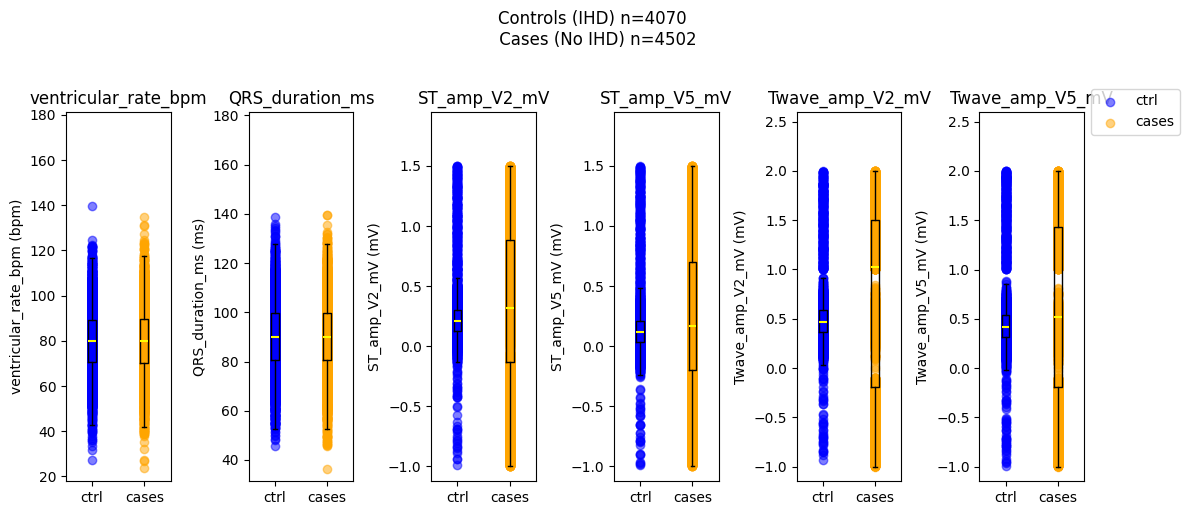

In [34]:

# define a function to plot the ECG biomarker values
# (you can read through it, but do not have to)
def boxplot_case_ctrl_columns(title_cases, title_ctrl, df_cases, df_ctrl, columns):
    """
    Inputs: df_cases, df_ctrl, columns as a list of str of common columns to cases and ctrls
    Outputs: boxplots of the columns selected
    """

    fig, axes = plt.subplots(nrows=1, ncols=len(columns), figsize=(12, 5))
    for i, column in enumerate(columns):
        try:
            row, col = divmod(i, 6)  # (i, ncols)
            ax = axes[row, col]
        except:
            ax=axes[i]

        # overlay data
        ax.scatter(np.ones_like(df_ctrl[column]), df_ctrl[column], color='blue', alpha=0.5, label='ctrl')
        ax.scatter(2 * np.ones_like(df_cases[column]), df_cases[column], color='orange', alpha=0.5, label='cases')

        # plot box plot
        bp=ax.boxplot([df_ctrl[column], df_cases[column]], positions=[1, 2], labels=['ctrl', 'cases'], showfliers=False)
        for median in bp['medians']:
            median.set(color='yellow', linewidth=1.5)
        ax.set_title(column)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['ctrl', 'cases'])
        ax.set_xlabel('')
        # ax.set_ylabel(f'Difference in {column} ({columns[column]})')
        ax.set_ylabel(f'{column} ({columns[column]})')
        if len(columns)!=12:
            ax.set_ylim(top=max(df_ctrl[column].max(), df_cases[column].max())*1.3)
        else:
            if max(df_ctrl[column].max(), df_cases[column].max()) > ymax:
                ymax=max(df_ctrl[column].max(), df_cases[column].max())
            if min(df_ctrl[column].min(), df_cases[column].min()) < ymin:
                ymin=min(df_ctrl[column].min(), df_cases[column].min())

        # # test for statistical significance
        # v1 = df_cases[column]
        # v2 = df_ctrl[column]
        # res = ttest_ind(v1, v2)  # independent t test
        # print(res)
        # if res.pvalue < 0.05:
        #     x1, x2 = 1,2
        #     y, h, col = max(df_ctrl[column].max(), df_cases[column].max())*1.1, 0, 'k'
        #     ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
        #     if res.pvalue < 0.01:
        #         ax.text((x1+x2)*.5, y+h, "** \n p < 0.01 \n", ha='center', va='bottom', color=col, linespacing = 0.8)
        #     else:
        #         ax.text((x1+x2)*.5, y+h, "* \n p < 0.05 \n", ha='center', va='bottom', color=col, linespacing = 0.8)

    ax.legend(loc='center left', bbox_to_anchor=(1, 1))

    # fig.suptitle(f'Single lead ECG markers for cases (T2DM w/ incident CVD) n={len(cases)} vs controls (T2DM w/o incident CVD) n={len(ctrl)}', y=1.02)
    fig.suptitle(f'Controls ({title_ctrl}) n={len(df_ctrl)} \n Cases ({title_cases}) n={len(df_cases)}', y=1.02)
    plt.tight_layout()
    plt.show()

    return

# prepare the variables you need for the function
cases_name = 'No IHD'
ctrl_name = 'IHD'
cases = df_complete[df_complete['ihd_flag']==1]
ctrl = df_complete[df_complete['ihd_flag']==0]
columns = {'ventricular_rate_bpm' : 'bpm',
           'QRS_duration_ms' : 'ms',
           'ST_amp_V2_mV' : 'mV',
            'ST_amp_V5_mV': 'mV',
            'Twave_amp_V2_mV': 'mV',
            'Twave_amp_V5_mV': 'mV',}

# apply the function
boxplot_case_ctrl_columns(cases_name, ctrl_name, cases, ctrl, columns)


In [36]:
#############################################################################
# TODO apply the correct statistical test to the 4 ECG biomarkers of interest
# hint: check out the code above for how to run a test for continuous distributions


# define continuous ECG biomarker columns
columns_ecg = ['eid', 'ventricular_rate_bpm', 'QRS_duration_ms', 'ST_amp_V2_mV', 'ST_amp_V5_mV', 'Twave_amp_V2_mV', 'Twave_amp_V5_mV']

# initialise list of dictionaries to store the results of the tests
results = []

# ------- your code here -------
for column in columns_ecg:

    # take specified column values for cases and controls
    cases = df_complete[df_complete['ihd_flag'] == 1][column].dropna()
    controls = df_complete[df_complete['ihd_flag'] == 0][column].dropna()

    # assess normality
    stat, p_shap_cases = shapiro(cases)
    stat, p_shap_ctrls = shapiro(controls)

    if (p_shap_cases > 0.05) | (p_shap_ctrls > 0.05):  # data looks normal
        test_name = 'Independent T-test'
        ttest_result = ttest_ind(cases, controls)  # independent t test
        p = ttest_result.pvalue

    else:  # data does NOT look normal
        test_name = 'Mann Whitney U-test'
        mannwhitneyu_result = mannwhitneyu(cases, controls)
        p = mannwhitneyu_result.pvalue

    results.append({
        'Variable': column,
        'Cases': len(cases),
        'Controls': len(controls),
        'Test performed': test_name,
        'P-value': p
    })


# -------------------------------

df_results_ecg = pd.DataFrame(results)
df_results_ecg

#############################################################################


,Variable,Cases,Controls,Test performed,P-value
0,eid,4502,4070,Mann Whitney U-test,3.977916e-01
1,ventricular_rate_bpm,4502,4070,Independent T-test,9.114153e-01
2,QRS_duration_ms,4502,4070,Independent T-test,9.639259e-01
3,ST_amp_V2_mV,4502,4070,Mann Whitney U-test,6.382270e-31
4,ST_amp_V5_mV,4502,4070,Mann Whitney U-test,1.603419e-07
5,Twave_amp_V2_mV,4502,4070,Mann Whitney U-test,2.031731e-41
6,Twave_amp_V5_mV,4502,4070,Mann Whitney U-test,9.406068e-14


What are some conclusions that may be inferred from the results you have just obtained?  

-->  The lower p-value metric indicates that it is likely that there is some quantifiable difference between the control and the cases group.

What may be a disadvantage of using these tests to assess continuous ECG variables like the ones above?

--> Using a pre-test that directs towards two distinct tests can artificially reduce the p-value, reducing the accuracy of our result.




In healthy individuals, average ST amplitude is around 0.2mV in lead V2 and 0.1mV in lead V5. T wave should be upright (positive amplitude) with an amplitude around 0.4mV in V5, slightly higher in V2.   

The following ECG criteria are key markers of IHD:

- hyperacute T wave: T wave amplitude is abnormal if it is above 1.0mV in leads V2 and V5  
- T wave inversion: an inverted T wave with a negative amplitude smaller than -0.1mV is abnormal  
- ST elevation: ST amplitude abnormal if above 0.2mV in lead V2, above 0.1mV in lead V5  
- ST depression: ST amplitude abnormal if below -0.05mV in lead V2, below -0.1mV in lead V5  

Let's assess whether we observe any differences in those criteria, in cases and controls.


In [37]:
#############################################################################
# TODO create 4 new columns to encode criteria above using 0/1
# the first one is done for you as an example

# hyperacute T wave
df_complete['hyperacute_T_wave'] = np.zeros(len(df_complete))
df_complete.loc[ (df_complete['Twave_amp_V2_mV'] > 1) | (df_complete['Twave_amp_V5_mV'] > 1), 'hyperacute_T_wave'] = 1

# T wave inversion
df_complete['T_wave_inversion'] = np.zeros(len(df_complete))
df_complete.loc[ (df_complete['Twave_amp_V2_mV'] < -0.1) | (df_complete['Twave_amp_V5_mV'] < -0.1), 'T_wave_inversion'] = 1

# ST elevation
df_complete['ST_elevation'] = np.zeros(len(df_complete))
df_complete.loc[ (df_complete['ST_amp_V2_mV'] > 0.2) | (df_complete['ST_amp_V5_mV'] < 0.1), 'ST_elevation'] = 1

# ST depression
df_complete['ST_depression'] = np.zeros(len(df_complete))
df_complete.loc[ (df_complete['ST_amp_V2_mV'] < -0.05) | (df_complete['ST_amp_V5_mV'] < -0.1), 'ST_depression'] = 1

# display results
df_complete

#############################################################################

,eid,131296-0.0,131298-0.0,131300-0.0,131304-0.0,131306-0.0,sbp_avg,dbp_avg,53-2.0,21003-2.0,...,ventricular_rate_bpm,QRS_duration_ms,ST_amp_V2_mV,ST_amp_V5_mV,Twave_amp_V2_mV,Twave_amp_V5_mV,hyperacute_T_wave,T_wave_inversion,ST_elevation,ST_depression
19,248960,1987-05-24,NaN,NaN,NaN,1983-06-13,127.00,76.75,2015-01-10 17:10:24.349647095,71.0,...,85.226380,94.735731,0.646547,-0.789568,-0.954976,-0.114677,0.0,1.0,1.0,1.0
29,433907,1996-11-07,NaN,NaN,NaN,NaN,136.50,77.75,2015-01-05 16:26:25.800853366,58.0,...,101.408686,93.097810,-0.276748,-0.996534,1.041423,0.480252,1.0,0.0,1.0,1.0
35,465792,NaN,2019-09-20,NaN,NaN,NaN,136.00,87.75,2014-11-24 11:58:05.879043603,62.0,...,57.770089,124.567499,-0.378219,0.101026,0.329799,0.406293,0.0,0.0,0.0,1.0
53,411797,NaN,NaN,1976-07-27,NaN,NaN,139.50,79.50,2014-07-08 01:23:58.492561203,76.0,...,113.038724,90.043743,-0.761080,0.413849,0.160417,1.483081,1.0,0.0,0.0,1.0
77,561250,NaN,NaN,NaN,NaN,NaN,136.75,78.50,2014-09-17 02:47:22.819967378,72.0,...,87.870613,89.165633,0.067444,0.084867,0.550279,0.445984,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95240,504495,NaN,2020-03-09,NaN,NaN,NaN,135.50,73.00,2016-03-16 16:25:58.927128880,66.0,...,70.967480,90.592381,0.253819,1.330301,0.435297,0.305639,0.0,0.0,1.0,0.0
95243,248725,NaN,NaN,NaN,2017-05-11,NaN,138.00,68.75,2015-04-27 08:28:22.437083270,67.0,...,74.504461,93.621955,0.092850,0.064390,0.498503,0.422813,0.0,0.0,1.0,0.0
95244,370698,NaN,1988-01-18,NaN,1991-03-28,1991-06-03,130.75,78.00,2016-09-08 16:42:38.584448338,65.0,...,45.710855,107.000743,-0.983119,-0.652788,0.399803,1.301511,1.0,0.0,1.0,1.0
95259,343066,NaN,2000-02-22,NaN,NaN,NaN,143.25,78.75,2016-04-02 00:58:12.897261212,53.0,...,112.638361,110.472775,0.345321,0.176606,1.906394,1.771125,1.0,0.0,1.0,0.0


In [38]:
#############################################################################
# TODO count the rate of occurrence of each criteria above, for cases and controls
# hint: in this case, the total number of occurrences is equal to the sum of each column (why?)

hyperacute_T_wave_cases = df_complete[df_complete['ihd_flag']==1]['hyperacute_T_wave'].sum() / len(df_complete[df_complete['ihd_flag']==1])
hyperacute_T_wave_ctrls = df_complete[df_complete['ihd_flag']==0]['hyperacute_T_wave'].sum() / len(df_complete[df_complete['ihd_flag']==0])

T_wave_inversion_cases = df_complete[df_complete['ihd_flag']==1]['T_wave_inversion'].sum() / len(df_complete[df_complete['ihd_flag']==1])
T_wave_inversion_ctrls = df_complete[df_complete['ihd_flag']==0]['T_wave_inversion'].sum() / len(df_complete[df_complete['ihd_flag']==0])

ST_elev_cases = df_complete[df_complete['ihd_flag']==1]['ST_elevation'].sum() / len(df_complete[df_complete['ihd_flag']==1])
ST_elev_ctrls = df_complete[df_complete['ihd_flag']==0]['ST_elevation'].sum() / len(df_complete[df_complete['ihd_flag']==0])

ST_depr_cases = df_complete[df_complete['ihd_flag']==1]['ST_depression'].sum() / len(df_complete[df_complete['ihd_flag']==1])
ST_depr_ctrls = df_complete[df_complete['ihd_flag']==0]['ST_depression'].sum() / len(df_complete[df_complete['ihd_flag']==0])

# print results. use the f'{}' format to include variables from your code in the print output
print('hyperacute_T_wave    ', f'cases: {hyperacute_T_wave_cases}   ', f'ctrls: {hyperacute_T_wave_ctrls}')
print('T_wave_inversion    ', f'cases: {T_wave_inversion_cases}   ', f'ctrls: {T_wave_inversion_ctrls}')
print('ST_elevation    ', f'cases: {ST_elev_cases}   ', f'ctrls: {ST_elev_ctrls}')
print('ST_depression    ', f'cases: {ST_depr_cases}   ', f'ctrls: {ST_depr_ctrls}')

#############################################################################



hyperacute_T_wave     cases: 0.7563305197689916    ctrls: 0.20417690417690418
T_wave_inversion     cases: 0.39804531319413594    ctrls: 0.023587223587223587
ST_elevation     cases: 0.8014215904042647    ctrls: 0.7417690417690418
ST_depression     cases: 0.4098178587294536    ctrls: 0.06732186732186732


In [39]:
#############################################################################
# TODO apply the correct statistical test to the 4 criteria we established
# hint: check out the code above for how to run a test for categorical distributions

# define the 4 categorical columns
columns_ecg = ["hyperacute_T_wave",	"T_wave_inversion",	"ST_elevation",	"ST_depression"]

# initialise list of dictionaries to store the results of the tests
results = []
# results = [{column+'_cases': 0, column+'_crtls':0} for column in columns_ecg]

# ------- your code here -------

for column in columns_ecg:

    # take specified column values for cases and controls
    cases = df_complete[df_complete['ihd_flag'] == 1][column]
    controls = df_complete[df_complete['ihd_flag'] == 0][column]

    # record the number of observations of each category (eg 0 or 1 for sex) for cases and controls
    observed = np.array([[np.sum(cases == i), np.sum(controls == i)] for i in np.unique(np.concatenate((cases, controls)))])

    # apply the chi2 test
    chi2, p, _, _ = chi2_contingency(observed)

    results.append({
        'Variable': column,
        'Cases': len(cases),
        'Controls': len(controls),
        'Chi-square statistic': chi2,
        'P-value': p
    })

# -------------------------------

df_results_categorical = pd.DataFrame(results)
df_results_categorical

#############################################################################

,Variable,Cases,Controls,Chi-square statistic,P-value
0,hyperacute_T_wave,4502,4070,2604.885480,0.000000e+00
1,T_wave_inversion,4502,4070,1743.039852,0.000000e+00
2,ST_elevation,4502,4070,43.022025,5.412706e-11
3,ST_depression,4502,4070,1345.572213,1.412118e-294


What conclusions may be inferred from these results?  What are the advantages/disadvantages of using this approach instead of comparing continuous distributions of biomarkers?

-->  From these p-values, we conclude that there is a meaningful difference between the healthy population and the people suffering from ischemia. Compared to continuous methods, this categorisation is simpler to understand but lacks granularity which may cause it to underperform in comparison with continuous methods.  